# High-Value Customer Behavior Simulation for a FinTech Subscription Service

## Section S03 — Data Analysis

This notebook evaluates synthetic fidelity using reusable analysis code from `src/analysis.py` and workflow metrics from `src/workflows.py`.


In [1]:
from src.notebook_utils import ensure_project_root_on_path, RAW_DATA, CHECKPOINT_DATA, SYNTHETIC_DIR
ensure_project_root_on_path()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')

from src.analysis import recover_parameters
from src.generators import get_generator
from src.workflows import compare_numeric_columns, create_vip_seed_data


In [2]:
real_df = create_vip_seed_data(samples=1000, random_state=42)
synth_df = get_generator('gan').generate(1000, random_state=42)
metrics = compare_numeric_columns(real_df, synth_df)
metrics


,column,real_mean,synthetic_mean,mean_delta,kl_divergence
0,avg_transaction,50.66778,118.63908,67.9713,1.387367
1,frequency,11.80200,10.90700,-0.8950,0.259235
2,credit_score,718.28000,700.15200,-18.1280,0.214399


In [3]:
trace = recover_parameters(synth_df, column='credit_score')
posterior_mu = float(trace.posterior['mu'].mean())
print({'posterior_mean_credit_score': round(posterior_mu, 2)})


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu, sigma]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 0 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


{'posterior_mean_credit_score': 700.21}


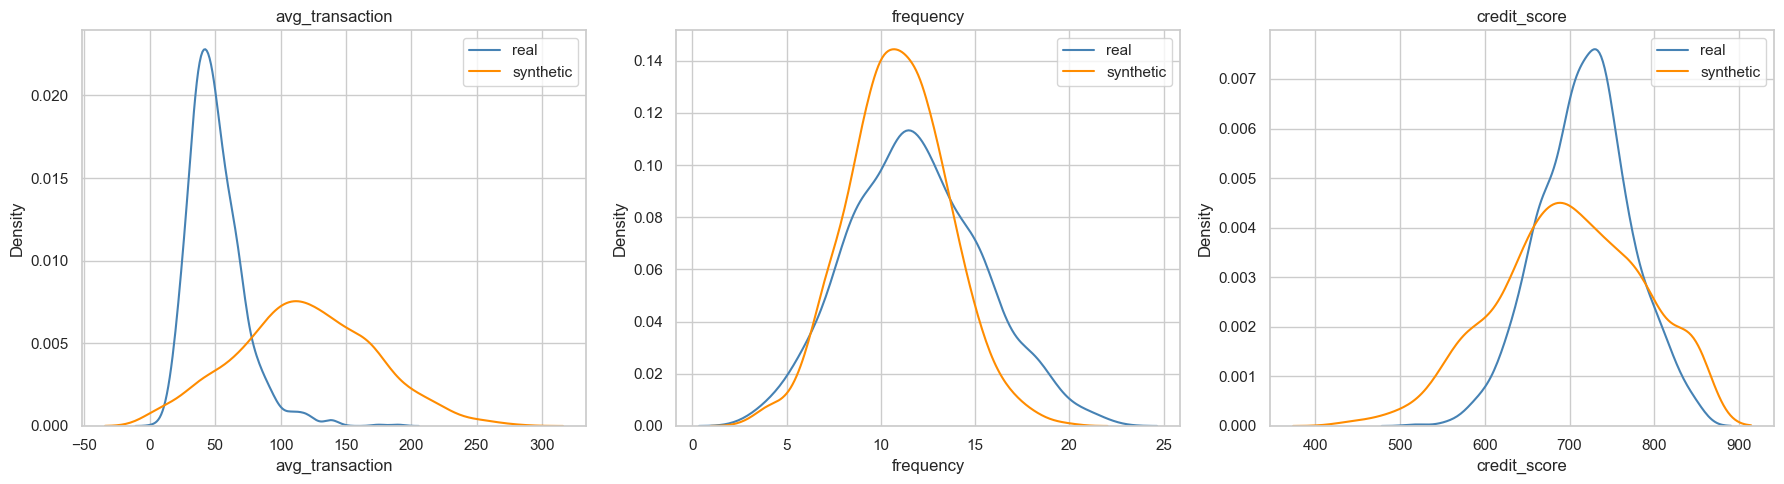

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, column in zip(axes, ['avg_transaction', 'frequency', 'credit_score']):
    sns.kdeplot(real_df[column], label='real', ax=ax, color='steelblue')
    sns.kdeplot(synth_df[column], label='synthetic', ax=ax, color='darkorange')
    ax.set_title(column)
    ax.legend()
plt.tight_layout()
